# Practical 8 — Geospatial Land Cover Segmentation with TorchGeo

Detection gives you bounding boxes. Segmentation gives you per-pixel class labels. For
wildlife monitoring that is the difference between *"there is a giraffe here"* and *"this
patch of savanna is 38 % open woodland, 12 % water, 50 % grassland"* — the habitat map
that underpins population density estimates and corridor planning.

This practical uses **[LandCover.ai](https://landcover.ai/)**, a freely available dataset of
Polish aerial orthophotos at 0.25 m/pixel with five hand-labelled land cover classes
(background, buildings, woodland, water, roads). The resolution and vegetation classes
are directly analogous to the drone imagery you worked with in Practicals 1–7.

We load the data with **[TorchGeo](https://torchgeo.readthedocs.io/)**, a PyTorch library
that wraps geospatial raster and vector datasets in a unified API. We then train a
**U-Net** (via `segmentation-models-pytorch`) and evaluate with per-class IoU.

**Environment:** `fit-training`  
**Key packages:** `torchgeo`, `segmentation-models-pytorch`, `torch`, `albumentations`

## Environment Setup

**Local (recommended):**
```bash
conda env create -f environment-training.yml
conda activate fit-training
```

**Google Colab:** uncomment and run the cell below.

In [1]:
# Colab only — install dependencies if not already available
# import sys

# !git clone  https://github.com/cwinkelmann/usde-innovations-applications-forest-it.git fit-course
# !cd fit-course && git pull
# !pip install -e "./fit-course[training,dev]"

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path

from torchgeo.datasets import LandCoverAI

import albumentations as A
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

DATA_DIR      = Path.cwd().parent / "data"
LANDCOVER_DIR = DATA_DIR / "landcoverai"
LANDCOVER_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Data dir : {DATA_DIR}")
print(f"LandCover: {LANDCOVER_DIR}")
print(f"Device   : {DEVICE}")

Data dir : /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/practicals/data
LandCover: /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/practicals/data/landcoverai
Device   : mps


---

## 1 — Dataset: LandCover.ai

LandCover.ai consists of **41 aerial orthophotos** (0.25 m/pixel) covering
countryside in Poland. Each pixel is labelled as one of five classes:

| ID | Class | Wildlife relevance |
|----|-------|-------------------|
| 0 | Background (bare soil, field) | Open habitat |
| 1 | Buildings | Human pressure |
| 2 | Woodland | Core wildlife habitat |
| 3 | Water | Drinking / dispersal corridor |
| 4 | Roads | Mortality risk / barrier |

TorchGeo pre-tiles the orthophotos into **512 × 512 px patches** for you.
The `download=True` flag fetches the data (~2.6 GB) on first run.

In [3]:
CLASS_NAMES  = ["Background", "Buildings", "Woodland", "Water", "Roads"]
CLASS_COLORS = ["#C8B89A", "#E74C3C", "#2ECC71", "#3498DB", "#7F8C8D"]
NUM_CLASSES  = len(CLASS_NAMES)

# torchgeo downloads, extracts, and caches the dataset automatically
train_ds = LandCoverAI(root=LANDCOVER_DIR, split="train", download=True)
val_ds   = LandCoverAI(root=LANDCOVER_DIR, split="val",   download=True)

print(f"Train patches : {len(train_ds)}")
print(f"Val   patches : {len(val_ds)}")

sample = train_ds[0]
print(f"\nSample keys   : {list(sample.keys())}")
print(f"Image shape   : {sample['image'].shape}   dtype={sample['image'].dtype}")
print(f"Mask  shape   : {sample['mask'].shape}    dtype={sample['mask'].dtype}")
print(f"Mask classes  : {sample['mask'].unique().tolist()}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1.02G/1.02G [00:24<00:00, 41.8MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 148k/148k [00:00<00:00, 6.42MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 31.8k/31.8k [00:00<00:00, 15.9MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 31.8k/31.8k [00:00<00:00, 19.4MB/s]


Train patches : 7470
Val   patches : 1602

Sample keys   : ['image', 'mask']
Image shape   : torch.Size([3, 512, 512])   dtype=torch.float32
Mask  shape   : torch.Size([512, 512])    dtype=torch.int64
Mask classes  : [0, 2]


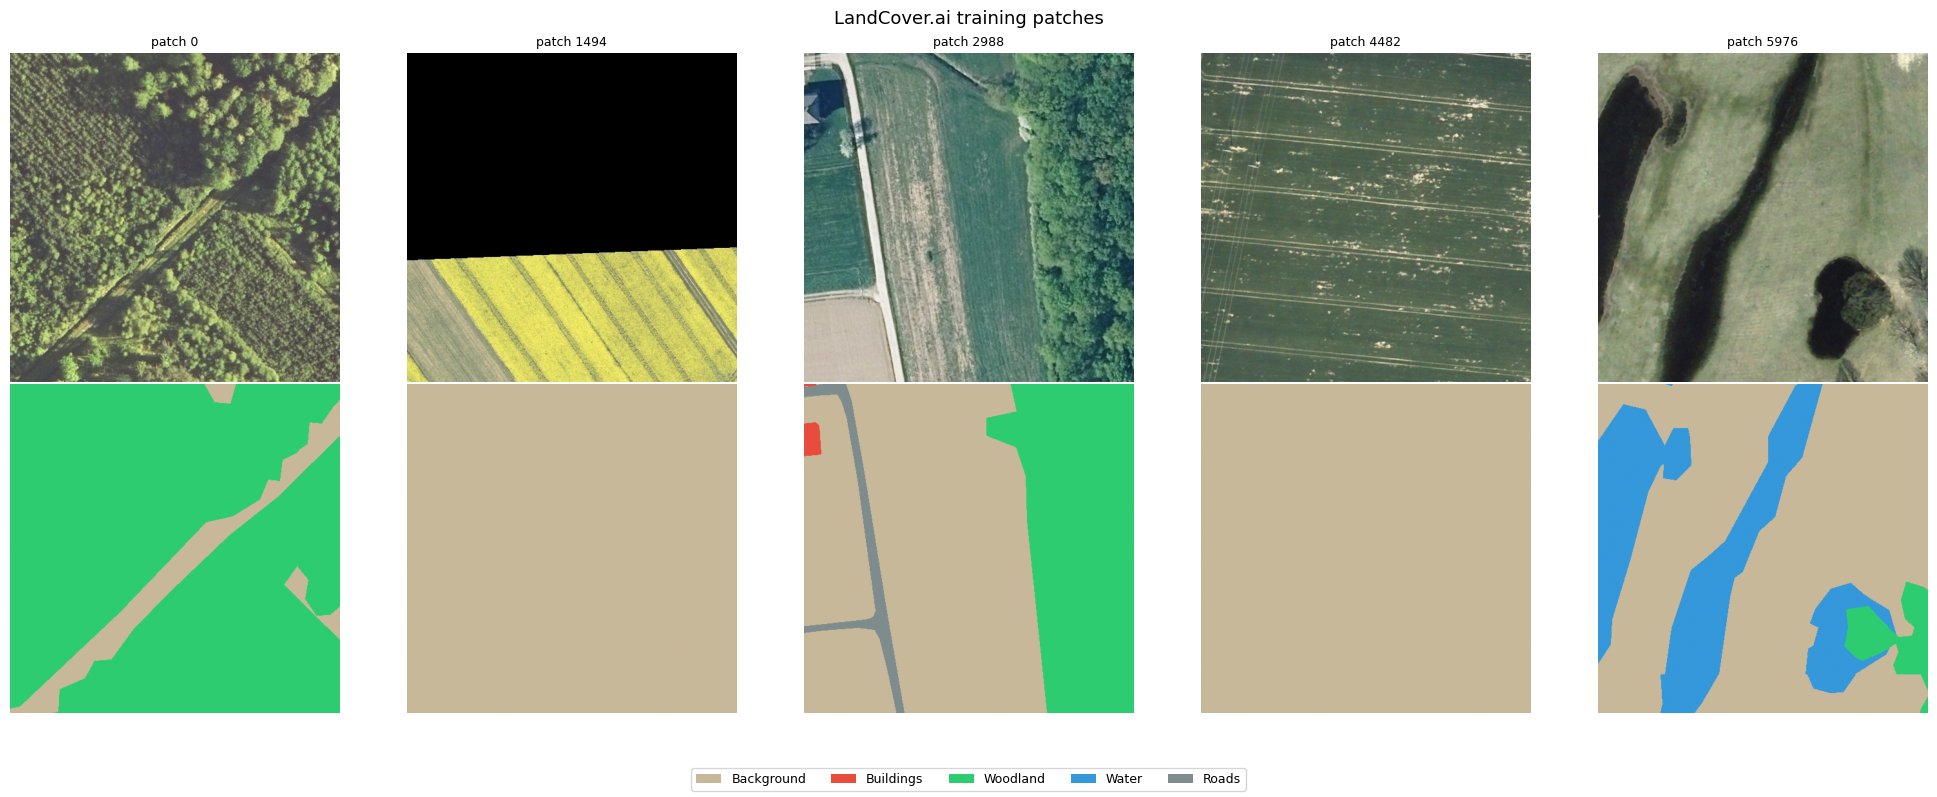

In [4]:
# Visualise a spread of training patches
cmap = mcolors.ListedColormap(CLASS_COLORS)
legend = [Patch(facecolor=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
step = max(1, len(train_ds) // 5)
for col, idx in enumerate(range(0, 5 * step, step)):
    s = train_ds[idx]
    img = s["image"].permute(1, 2, 0).numpy()
    img = (img / img.max() * 255).clip(0, 255).astype(np.uint8) if img.max() > 1 else img
    msk = s["mask"].squeeze().numpy()

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"patch {idx}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(msk, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("RGB (0.25 m/px)", fontsize=10)
axes[1, 0].set_ylabel("Land Cover Label", fontsize=10)
fig.legend(handles=legend, loc="lower center", ncol=NUM_CLASSES, fontsize=9)
plt.suptitle("LandCover.ai training patches", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

---

## 2 — TorchGeo: GeoDataset vs NonGeoDataset

TorchGeo has two dataset base classes:

| Class | What it stores | Indexing |
|-------|---------------|----------|
| **`GeoDataset`** | Geospatially referenced rasters (GeoTIFF, Shapefile, …) | `BoundingBox(minx, maxx, miny, maxy, mint, maxt)` — any window, any time |
| **`NonGeoDataset`** | Pre-tiled image/mask pairs (like ImageFolder) | Integer index |

`LandCoverAI` is a **`NonGeoDataset`** — it gives you pre-tiled 512 × 512 patches.
For the full orthophoto GeoTIFF files, TorchGeo also provides `LandCoverAIGeo` (a
`GeoDataset`). With a `GeoDataset` you use **samplers** instead of integer indices:

```python
from torchgeo.datasets import LandCoverAIGeo
from torchgeo.samplers import RandomGeoSampler, GridGeoSampler
from torchgeo.datasets.utils import stack_samples

# Load raw orthophotos + masks as a geospatially-aligned pair
dataset = LandCoverAIGeo(root=LANDCOVER_DIR)

# Random windows for training  — 256×256 px, 1 000 samples per epoch
train_sampler = RandomGeoSampler(dataset, size=256, length=1000)
# Regular grid for inference   — 256×256 px, no overlap
infer_sampler = GridGeoSampler(dataset, size=256, stride=256)

loader = DataLoader(dataset, batch_size=4,
                    sampler=train_sampler, collate_fn=stack_samples)
batch = next(iter(loader))
# batch["image"]  (4, 3, 256, 256) float tensor
# batch["mask"]   (4, 1, 256, 256) long tensor
# batch["crs"]    coordinate reference system, e.g. EPSG:32634
# batch["bbox"]   BoundingBox(minx, maxx, miny, maxy, mint, maxt)
```

The `BoundingBox` ties every patch to real-world coordinates, which lets you:
- Mosaic predictions back into a geo-referenced output raster
- Join imagery from different sensors by spatial overlap
- Filter samples by region or acquisition date

We use `LandCoverAI` (NonGeoDataset) below for simplicity.

---

## 3 — Training Pipeline

In [5]:
BATCH_SIZE = 4
CROP_SIZE  = 256   # random crop from the 512×512 patch

# Albumentations expects numpy float32 (H, W, C).  TorchGeo returns float tensors
# — this thin wrapper bridges the two APIs.
class SegDataset(Dataset):
    """Wraps a torchgeo NonGeoDataset and applies albumentations transforms."""

    def __init__(self, torchgeo_ds, transform=None):
        self.ds        = torchgeo_ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        # image: (3, H, W) float tensor  → (H, W, 3) float32 numpy
        img = sample["image"].permute(1, 2, 0).numpy().astype(np.float32)
        if img.max() > 1.0:
            img /= 255.0
        # mask: (H, W) or (1, H, W) long tensor → (H, W) uint8 numpy
        msk = sample["mask"].squeeze().numpy().astype(np.uint8)

        if self.transform:
            t   = self.transform(image=img, mask=msk)
            img = t["image"]
            msk = t["mask"]

        img_t = torch.from_numpy(img).permute(2, 0, 1).float()
        msk_t = torch.from_numpy(np.array(msk)).long()
        return img_t, msk_t


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# max_pixel_value=1.0 because SegDataset already rescales images to [0, 1].
# Without this, Albumentations divides by 255 a second time → all-black inputs.
train_tf = A.Compose([
    A.RandomCrop(CROP_SIZE, CROP_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=1.0),
])
val_tf = A.Compose([
    A.CenterCrop(CROP_SIZE, CROP_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=1.0),
])

train_wrapped = SegDataset(train_ds, transform=train_tf)
val_wrapped   = SegDataset(val_ds,   transform=val_tf)

train_dl = DataLoader(train_wrapped, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_wrapped,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imgs, masks = next(iter(train_dl))
print(f"Image batch : {imgs.shape}   range=[{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"Mask  batch : {masks.shape}  classes={masks.unique().tolist()}")

Image batch : torch.Size([4, 3, 256, 256])   range=[-2.10, 2.08]
Mask  batch : torch.Size([4, 256, 256])  classes=[0, 1, 2, 3, 4]


---

## 4 — U-Net Model

`segmentation-models-pytorch` provides U-Net (and DeepLabV3+, FPN, …) with any
torchvision/timm encoder backbone. We use **ResNet18** — small enough for a laptop
GPU but deep enough to segment fine structures like tree canopy edges.

We combine two complementary losses:
- **Cross-entropy** — per-pixel class probability, treats all classes equally
- **Dice loss** — directly optimises the IoU-like overlap, compensates for class imbalance
  (Background ≫ Buildings/Water/Roads in pixel count)

In [6]:
model = smp.Unet(
    encoder_name    = "resnet18",
    encoder_weights = "imagenet",   # ImageNet pretraining
    in_channels     = 3,
    classes         = NUM_CLASSES,
).to(DEVICE)

# Freeze the ImageNet encoder — only the U-Net decoder is trained.
# Cuts trainable parameters ~11 M → ~2 M and each step runs ~3× faster.
# Set FREEZE_ENCODER = False to fine-tune the full network (best accuracy).
FREEZE_ENCODER = True
if FREEZE_ENCODER:
    for param in model.encoder.parameters():
        param.requires_grad = False

# Combined CE + Dice loss for class-imbalanced segmentation
ce_loss   = smp.losses.SoftCrossEntropyLoss(smooth_factor=0.1)
dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
loss_fn   = lambda logits, mask: 0.5 * ce_loss(logits, mask) + 0.5 * dice_loss(logits, mask)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=3e-4
)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net ResNet18 — total {n_total:,} params, trainable {n_trainable:,}")
print(f"Encoder frozen : {FREEZE_ENCODER}")
print(f"Input : (B, 3, {CROP_SIZE}, {CROP_SIZE})")
print(f"Output: (B, {NUM_CLASSES}, {CROP_SIZE}, {CROP_SIZE})")

U-Net ResNet18 — total 14,328,789 params, trainable 3,152,277
Encoder frozen : True
Input : (B, 3, 256, 256)
Output: (B, 5, 256, 256)


Train the model

In [7]:
# ── Demo / production knobs ─────────────────────────────────────────────────
# Demo  (CPU ~60 s) : EPOCHS=3,  STEPS_PER_EPOCH=30
# Light GPU (~5 min): EPOCHS=10, STEPS_PER_EPOCH=200
# Full  training    : EPOCHS=30, STEPS_PER_EPOCH=None  (uses all ~1 750 steps)
EPOCHS          = 5     # ← set to 30–50 for production quality
STEPS_PER_EPOCH = None    # ← set to None to iterate the full training set
# ─────────────────────────────────────────────────────────────────────────────

CKPT_PATH  = DATA_DIR / "unet_landcoverai_best.pt"
steps_epoch = STEPS_PER_EPOCH or len(train_dl)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-4,
    steps_per_epoch=steps_epoch, epochs=EPOCHS,
)

train_losses, val_losses = [], []
best_val = float("inf")

for epoch in range(EPOCHS):
    # ── train (optionally capped) ─────────────────────────────────────────
    model.train()
    t_loss, t_steps = 0.0, 0
    for step, (imgs_b, masks_b) in enumerate(train_dl):
        if STEPS_PER_EPOCH and step >= STEPS_PER_EPOCH:
            break
        imgs_b  = imgs_b.to(DEVICE)
        masks_b = masks_b.to(DEVICE)
        logits  = model(imgs_b)
        loss    = loss_fn(logits, masks_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        t_loss  += loss.item()
        t_steps += 1

    # ── validate ──────────────────────────────────────────────────────────
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for imgs_b, masks_b in val_dl:
            logits  = model(imgs_b.to(DEVICE))
            v_loss += loss_fn(logits, masks_b.to(DEVICE)).item()

    t_avg = t_loss / t_steps
    v_avg = v_loss / len(val_dl)
    train_losses.append(t_avg)
    val_losses.append(v_avg)

    if v_avg < best_val:
        best_val = v_avg
        torch.save(model.state_dict(), CKPT_PATH)

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"train={t_avg:.4f} ({t_steps} steps)  val={v_avg:.4f}"
          f"{'  ← best' if v_avg == best_val else ''}")

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print(f"\nLoaded best checkpoint (val={best_val:.4f})")

Epoch  1/5  train=0.7107 (1868 steps)  val=0.4889  ← best
Epoch  2/5  train=0.5619 (1868 steps)  val=0.4667  ← best
Epoch  3/5  train=0.5133 (1868 steps)  val=0.4564  ← best
Epoch  4/5  train=0.4754 (1868 steps)  val=0.4302  ← best
Epoch  5/5  train=0.4545 (1868 steps)  val=0.4114  ← best

Loaded best checkpoint (val=0.4114)


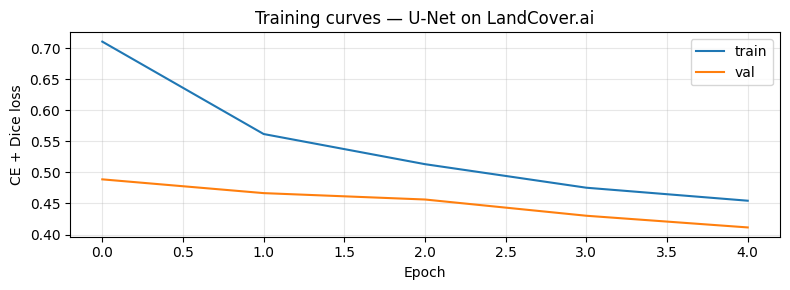

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("CE + Dice loss")
ax.set_title("Training curves — U-Net on LandCover.ai")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

---

## 5 — Evaluation: per-class IoU

Per-class IoU & Dice on validation set:
     class   IoU  Dice
Background 0.869 0.930
 Buildings 0.599 0.749
  Woodland 0.830 0.907
     Water 0.741 0.851
     Roads 0.457 0.627
      mean 0.699 0.813


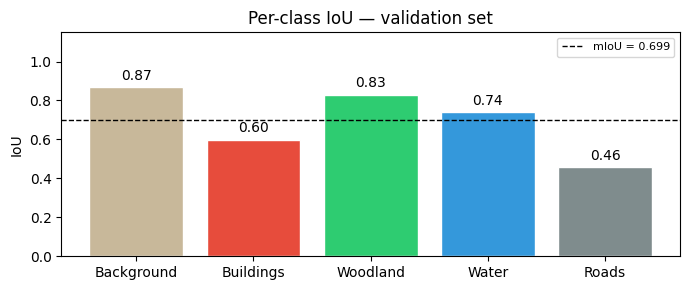

In [9]:
import pandas as pd

def compute_iou(model, loader, num_classes, device):
    """Accumulate confusion matrix over the full loader, return per-class IoU."""
    conf = np.zeros((num_classes, num_classes), dtype=np.int64)
    model.eval()
    with torch.no_grad():
        for imgs_b, masks_b in loader:
            preds = model(imgs_b.to(device)).argmax(1).cpu().numpy().ravel()
            gt    = masks_b.numpy().ravel()
            valid = gt < num_classes
            np.add.at(conf, (gt[valid], preds[valid]), 1)

    rows = []
    for c in range(num_classes):
        tp = conf[c, c]
        fp = conf[:, c].sum() - tp
        fn = conf[c, :].sum() - tp
        iou  = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else float("nan")
        dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else float("nan")
        rows.append({"class": CLASS_NAMES[c], "IoU": round(iou, 3), "Dice": round(dice, 3)})
    df = pd.DataFrame(rows)
    df.loc[len(df)] = ["mean", df["IoU"].mean().round(3), df["Dice"].mean().round(3)]
    return df

metrics = compute_iou(model, val_dl, NUM_CLASSES, DEVICE)
print("Per-class IoU & Dice on validation set:")
print(metrics.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
class_rows = metrics[metrics["class"] != "mean"]
bars = ax.bar(class_rows["class"], class_rows["IoU"],
              color=CLASS_COLORS, edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=3)
mean_iou = metrics.loc[metrics["class"] == "mean", "IoU"].values[0]
ax.axhline(mean_iou, color="black", linestyle="--", linewidth=1, label=f"mIoU = {mean_iou:.3f}")
ax.set_ylim(0, 1.15)
ax.set_ylabel("IoU")
ax.set_title("Per-class IoU — validation set")
ax.legend(fontsize=8)
plt.tight_layout()

---

## 6 — Visualise Predictions

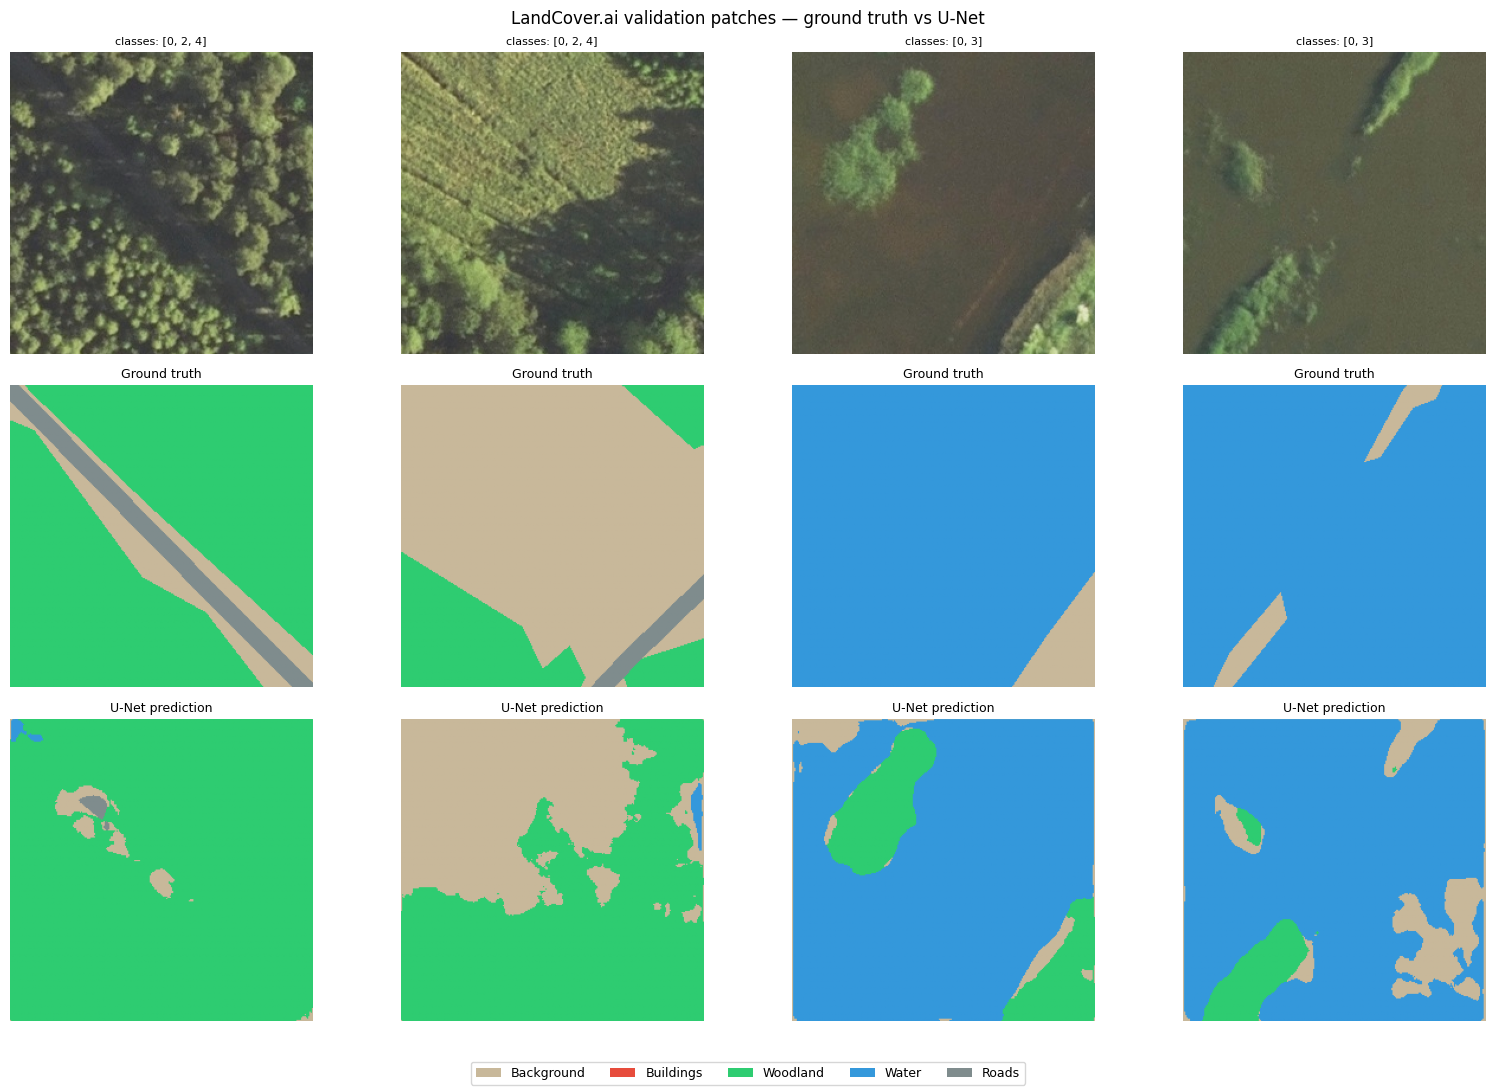

In [10]:
def predict_patch(model, img_tensor, device):
    """Run model on a single normalised (3, H, W) float tensor."""
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
    return logits.argmax(1).squeeze().cpu().numpy()

def denorm(img_tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = img_tensor.cpu() * std + mean
    return (img.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)

# Find 4 val patches that each contain at least 2 distinct classes,
# preferring patches with rare classes (buildings=1, water=3, roads=4).
RARE_CLASSES = {1, 3, 4}
selected = []
for imgs_b, masks_b in val_dl:
    for j in range(imgs_b.shape[0]):
        classes_present = set(masks_b[j].unique().tolist())
        if len(classes_present) >= 2 and classes_present & RARE_CLASSES:
            selected.append((imgs_b[j], masks_b[j]))
        if len(selected) == 4:
            break
    if len(selected) == 4:
        break

# Fallback: any multi-class patch
if len(selected) < 4:
    for imgs_b, masks_b in val_dl:
        for j in range(imgs_b.shape[0]):
            if len(set(masks_b[j].unique().tolist())) >= 2:
                selected.append((imgs_b[j], masks_b[j]))
            if len(selected) == 4:
                break
        if len(selected) == 4:
            break

n_show = len(selected)
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 11))
for i, (img_t, msk_t) in enumerate(selected):
    pred = predict_patch(model, img_t, DEVICE)
    gt   = msk_t.numpy()

    axes[0, i].imshow(denorm(img_t))
    axes[0, i].set_title(f"classes: {sorted(set(gt.ravel().tolist()))}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(gt,   cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1, i].set_title("Ground truth", fontsize=9)
    axes[1, i].axis("off")

    axes[2, i].imshow(pred, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[2, i].set_title("U-Net prediction", fontsize=9)
    axes[2, i].axis("off")

for row_label, ax_row in zip(["RGB input", "Ground truth", "U-Net pred"], axes[:, 0]):
    ax_row.set_ylabel(row_label, fontsize=10)

fig.legend(handles=legend, loc="lower center", ncol=NUM_CLASSES, fontsize=9)
plt.suptitle("LandCover.ai validation patches — ground truth vs U-Net", fontsize=12)
plt.tight_layout()
plt.subplots_adjust(bottom=0.06)

In [11]:
from torchgeo.datasets import LandCoverAIGeo
from torchgeo.samplers import GridGeoSampler

# Geo-referenced version: raw GeoTIFFs, not pre-tiled patches
geo_ds = LandCoverAIGeo(root=LANDCOVER_DIR)

# Resolution in CRS units per pixel (metres for UTM / EPSG:32634, ≈ 0.25)
res = geo_ds.res
if not isinstance(res, (int, float)):   # some TorchGeo versions return a tuple
    res = res[0]

# ── carve a 2048×2048 px region from the top-left of the dataset extent ──────
CANVAS_PX = 2048
extent_m  = CANVAS_PX * res
b    = geo_ds.bounds                        # BoundingBox of full dataset
BBox = b.__class__                          # reuse the same namedtuple type
roi  = BBox(
    minx=b.minx,           maxx=b.minx + extent_m,
    miny=b.maxy - extent_m, maxy=b.maxy,   # top-left anchor, y-axis down
    mint=b.mint,           maxt=b.maxt,
)

# Non-overlapping 256-px tile grid over the region
tile_m  = CROP_SIZE * res                   # e.g. 256 px × 0.25 m/px = 64 m
sampler = GridGeoSampler(geo_ds, size=tile_m, stride=tile_m, roi=roi)

MEAN_T = np.array(IMAGENET_MEAN, dtype=np.float32).reshape(3, 1, 1)
STD_T  = np.array(IMAGENET_STD,  dtype=np.float32).reshape(3, 1, 1)

canvas_rgb  = np.zeros((CANVAS_PX, CANVAS_PX, 3), dtype=np.uint8)
canvas_gt   = np.zeros((CANVAS_PX, CANVAS_PX),    dtype=np.uint8)
canvas_pred = np.zeros((CANVAS_PX, CANVAS_PX),    dtype=np.uint8)

model.eval()
n_tiles = 0
with torch.no_grad():
    for query in sampler:
        sample = geo_ds[query]
        img = sample["image"]           # (3, H, W) float tensor
        msk = sample["mask"].squeeze()  # (H, W) long tensor

        img_np = img.permute(1, 2, 0).numpy().astype(np.float32)
        if img_np.max() > 1.0:
            img_np /= 255.0
        h, w = img_np.shape[:2]

        # Convert geographic bbox → pixel offset within canvas
        col = round((query.minx - roi.minx) / res)
        row = round((roi.maxy  - query.maxy) / res)   # y increases downward
        if row < 0 or col < 0 or row + h > CANVAS_PX or col + w > CANVAS_PX:
            continue

        # Inference (same normalisation as training)
        tile_norm = (img_np.transpose(2, 0, 1) - MEAN_T) / STD_T
        logits    = model(torch.from_numpy(tile_norm).float().unsqueeze(0).to(DEVICE))
        pred      = logits.argmax(1).squeeze().cpu().numpy().astype(np.uint8)

        canvas_rgb [row:row+h, col:col+w] = (img_np * 255).clip(0, 255).astype(np.uint8)
        canvas_gt  [row:row+h, col:col+w] = msk.numpy().astype(np.uint8)
        canvas_pred[row:row+h, col:col+w] = pred
        n_tiles += 1

print(f"Stitched {n_tiles} tiles into {CANVAS_PX}×{CANVAS_PX} px canvas")

area_ha = (CANVAS_PX * res) ** 2 / 10_000
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, arr, title, cm in zip(
    axes,
    [canvas_rgb, canvas_gt, canvas_pred],
    ["RGB (0.25 m/px)", "Ground truth", "U-Net prediction"],
    [None, cmap, cmap],
):
    kw = dict(cmap=cm, vmin=0, vmax=NUM_CLASSES - 1) if cm else {}
    ax.imshow(arr, **kw)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

fig.legend(handles=legend, loc="lower center", ncol=NUM_CLASSES, fontsize=9)
plt.suptitle(
    f"Full-scene inference — {CANVAS_PX}×{CANVAS_PX} px  "
    f"(≈ {CANVAS_PX*res:.0f} × {CANVAS_PX*res:.0f} m,  {area_ha:.1f} ha)",
    fontsize=13,
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.07)

DatasetNotFoundError: Dataset not found in `root=PosixPath('/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/practicals/data/landcoverai')` and `download=False`, either specify a different `root` or use `download=True` to automatically download the dataset.

---

## 7 — Full-scene inference on a continuous orthophoto region

The tile-level visualisation above shows isolated 256 × 256 px patches.
Here we use **`LandCoverAIGeo`** — the geo-referenced version of the dataset — to
sample a contiguous **2048 × 2048 px** region with a non-overlapping grid, run
inference on each tile, and stitch the predictions back into a single image using
the geographic bounding-box of each tile as its pixel offset.

At 0.25 m/pixel that covers roughly **512 × 512 m ≈ 26 ha** in one view.

In [ ]:
## TODO how can I replace the dataset with a personal dataset of i.e. SAR geotiffs and shapefiles wich contain segmenttaion masks?

---

## Exercises

1. **Backbone swap** — change `encoder_name` from `"resnet18"` to `"resnet34"` or
   `"efficientnet-b0"`. Does a larger encoder improve Woodland IoU, and by how much?

2. **Loss ablation** — train with only Cross-entropy (remove the Dice term). Compare
   the IoU for the rare classes (Water, Roads). Why does Dice help with class imbalance?

3. **GeoDataset inference** — Replace `LandCoverAI` with `LandCoverAIGeo` and use
   `GridGeoSampler` to run inference on the full orthophoto. Write the predictions back
   to a GeoTIFF with `rasterio` so you can open the result in QGIS.

4. **Architecture** — swap U-Net for `smp.DeepLabV3Plus` (same encoder). How does the
   receptive field difference affect predictions at woodland edges?

5. **Wildlife link** — The Woodland class directly represents potential wildlife habitat.
   Write a short pipeline that (a) runs the U-Net to produce a woodland mask, and
   (b) counts woodland patches and estimates total area in hectares using the 0.25 m/px
   resolution. What would you need to do differently for the Eikelboom drone tiles?

## Reflection

- LandCover.ai is Polish countryside, not African savanna. Which classes would you
  add or rename for a Serengeti or Eikelboom habitat map?

- U-Net achieves high Woodland IoU (typically 0.85+) at 10 epochs because the
  class is spectrally distinct (green). Which class is hardest to segment, and why?

- `NonGeoDataset` is simpler to use but discards geospatial coordinates. When does
  that matter? What would you lose if you used it for a real habitat-mapping deployment?

- **Bridge to Week 2:** Next week you will apply segmentation to Sentinel-1 SAR
  imagery for Galamsey (illegal gold mining) detection. The pixel values change from
  RGB reflectance to radar backscatter, but the U-Net architecture and TorchGeo
  `GeoDataset` pattern stay the same.